In [14]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT / "src"))
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "GBP_FX_BoE_10y.csv"
TARGET = "GBP-CNY"

## Data Loading and Preprocessing

In [19]:
from fx_forecasting.data.load import load_fx_csv
from fx_forecasting.data.preprocess import prepare_fx_data
from fx_forecasting.data.inspect import inspect_data

df, columns = load_fx_csv(DATA_PATH)

# Assume LSTM model
X_train, y_train, X_test, y_test, scaler = prepare_fx_data(
    df,
    target_col=TARGET,
    test_ratio=0.2,
    add_returns=False,
    add_ma=False,
    add_volatility=False,
    scale=True,
    scaler_type="standard",
    make_windows=True,
    lookback=30
)

feature_columns = [c for c in columns if c != TARGET]
print(feature_columns)

['GBP-USD', 'GBP-EUR', 'GBP-JPY', 'GBP-KRW', 'GBP-CHF']


/Users/apple/COMP0197-group-project/src/fx_forecasting/data/load.py:32: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["timestamp"] = pd.to_datetime(df[date_col], errors="coerce")


In [20]:
# Inspect Data
inspect_data(df)


Shape: (2779, 7)

Columns:
['timestamp', 'GBP-CNY', 'GBP-USD', 'GBP-EUR', 'GBP-JPY', 'GBP-KRW', 'GBP-CHF']

First rows:
   timestamp  GBP-CNY  GBP-USD  GBP-EUR   GBP-JPY    GBP-KRW  GBP-CHF
0 2015-01-02   9.5476   1.5388   1.2790  184.9638  1702.0821   1.5373
1 2015-01-05   9.4794   1.5240   1.2767  182.2552  1690.7256   1.5338
2 2015-01-06   9.4244   1.5170   1.2727  180.0831  1670.4901   1.5287
3 2015-01-07   9.3582   1.5063   1.2762  179.9275  1661.7351   1.5327
4 2015-01-08   9.3724   1.5082   1.2789  180.5014  1654.6764   1.5363

Data types:
timestamp    datetime64[us]
GBP-CNY             float64
GBP-USD             float64
GBP-EUR             float64
GBP-JPY             float64
GBP-KRW             float64
GBP-CHF             float64
dtype: object

Missing values:
timestamp    0
GBP-CNY      0
GBP-USD      0
GBP-EUR      0
GBP-JPY      0
GBP-KRW      0
GBP-CHF      0
dtype: int64

Date range:
Start: 2015-01-02 00:00:00
End: 2025-12-31 00:00:00

Observed time gaps:
timestamp
1 days

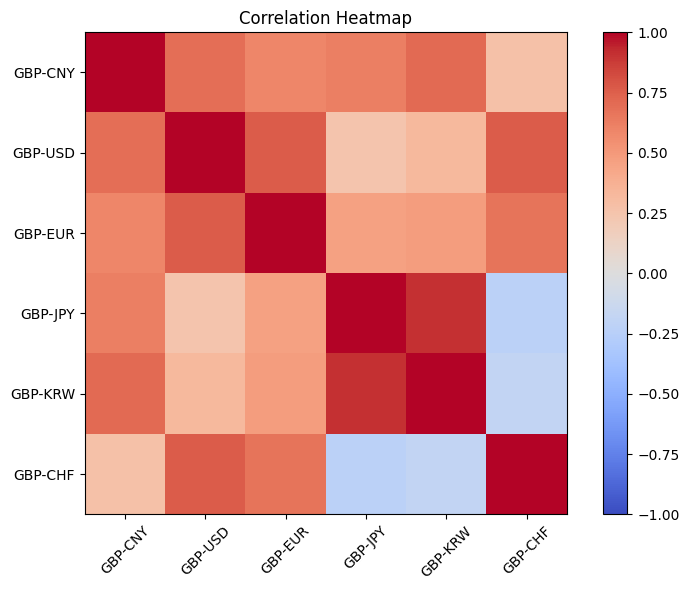

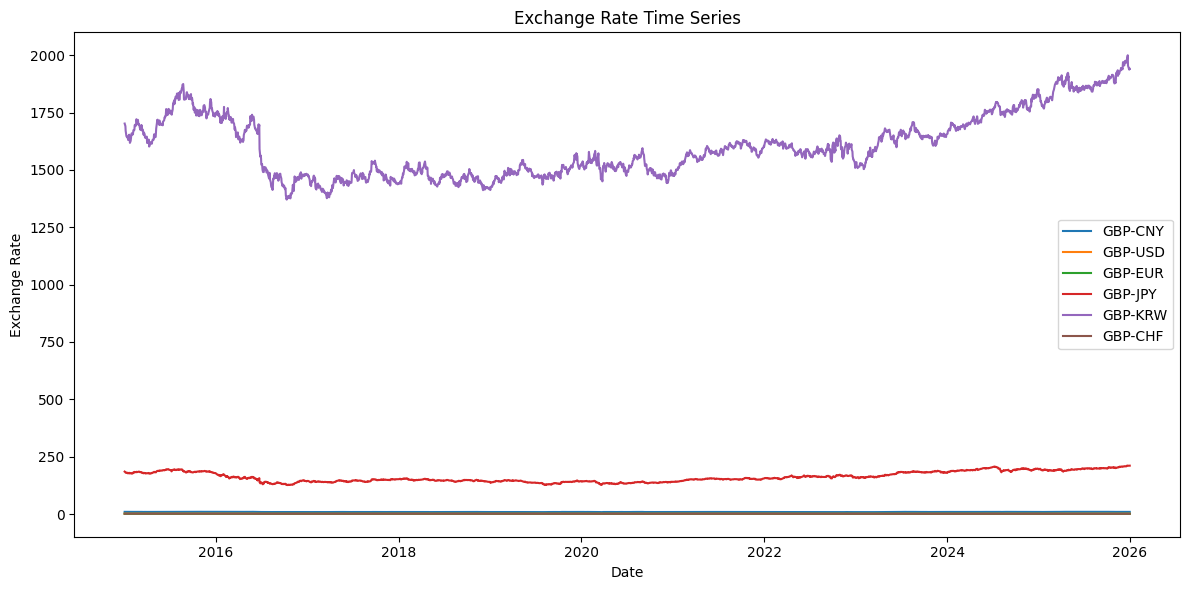

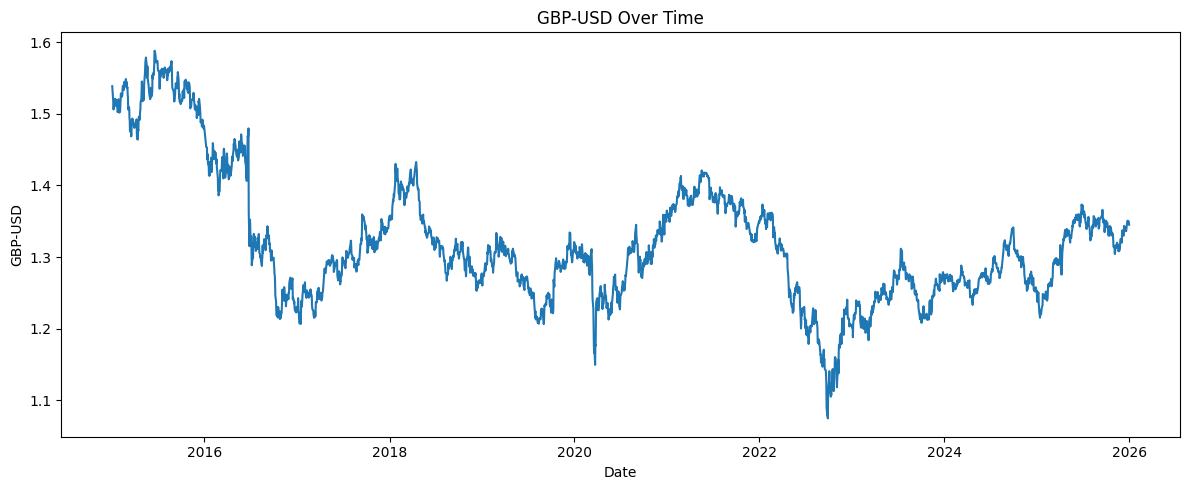

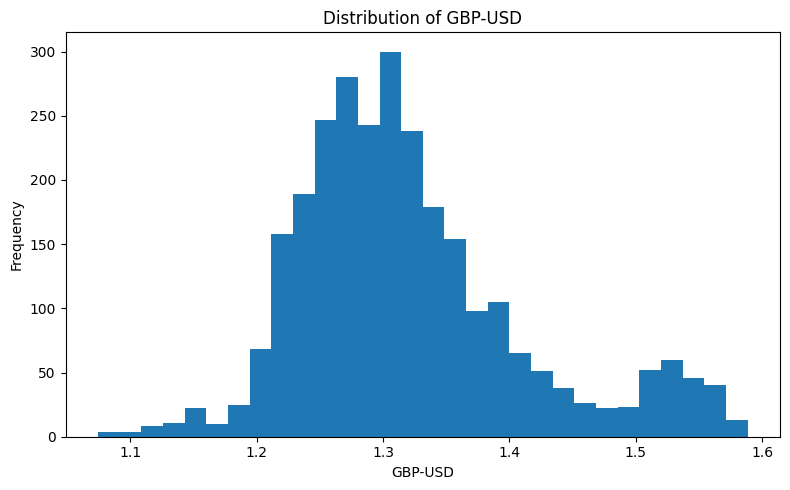

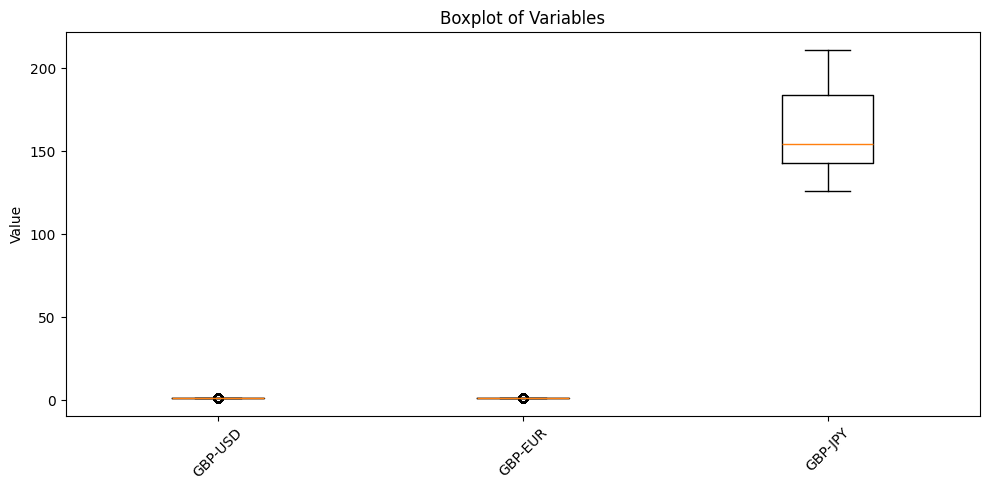

In [21]:
# visualisations

from fx_forecasting.visualization.plots import (
    plot_all_series,
    plot_target_series,
    plot_histogram,
    plot_boxplot,
    plot_correlation_heatmap
)

plot_correlation_heatmap(df)
plot_all_series(df)
plot_target_series(df, "GBP-USD")
plot_histogram(df, "GBP-USD")
plot_boxplot(df, cols=["GBP-USD", "GBP-EUR", "GBP-JPY"])

## Model Training

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# Hyperparameters
HIDDEN_DIM = 64
NUM_LAYERS = 2
LR = 0.001
EPOCHS = 20
BATCH_SIZE = 64


In [23]:
# Data loaders
from torch.utils.data import TensorDataset, DataLoader

# convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# datasets
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_test_t, y_test_t)

# dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [29]:
from fx_forecasting.models.baseline import DeterministicLSTM
from fx_forecasting.training.train import train_model


model = DeterministicLSTM(
    input_dim=X_train.shape[2],
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS
)

# Optimizer and loss
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss() 
device = "cuda" if torch.cuda.is_available() else "cpu"

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=EPOCHS,
    device=device,
    save_path="best_baseline_model.pt",
    early_stopping_patience=4
)

Epoch 1/20 [Val]: 100%|██████████| 9/9 [00:00<00:00, 232.12it/s]


Epoch 1/20 | Train Loss: 0.5753 | Val Loss: 1.2474 | Train MAE: 0.5730 | Val MAE: 1.0576 | Train RMSE: 0.7430 | Val RMSE: 1.0808
Saved best model at epoch 1 with val loss 1.2474


Epoch 2/20 [Val]: 100%|██████████| 9/9 [00:00<00:00, 212.07it/s]


Epoch 2/20 | Train Loss: 0.2901 | Val Loss: 0.2289 | Train MAE: 0.4138 | Val MAE: 0.4185 | Train RMSE: 0.5341 | Val RMSE: 0.4568
Saved best model at epoch 2 with val loss 0.2289


Epoch 3/20 [Val]: 100%|██████████| 9/9 [00:00<00:00, 228.76it/s]


...

Epoch 6/20 | Train Loss: 0.1013 | Val Loss: 0.2971 | Train MAE: 0.2464 | Val MAE: 0.4718 | Train RMSE: 0.3160 | Val RMSE: 0.5110


Epoch 7/20 [Val]: 100%|██████████| 9/9 [00:00<00:00, 239.66it/s]


Epoch 7/20 | Train Loss: 0.0920 | Val Loss: 0.4140 | Train MAE: 0.2352 | Val MAE: 0.5632 | Train RMSE: 0.3023 | Val RMSE: 0.6016


Epoch 8/20 [Val]: 100%|██████████| 9/9 [00:00<00:00, 233.80it/s]

Epoch 8/20 | Train Loss: 0.0841 | Val Loss: 0.3682 | Train MAE: 0.2238 | Val MAE: 0.5325 | Train RMSE: 0.2875 | Val RMSE: 0.5694
Early stopping at epoch 8
Best model was from epoch 4 with val loss 0.1996


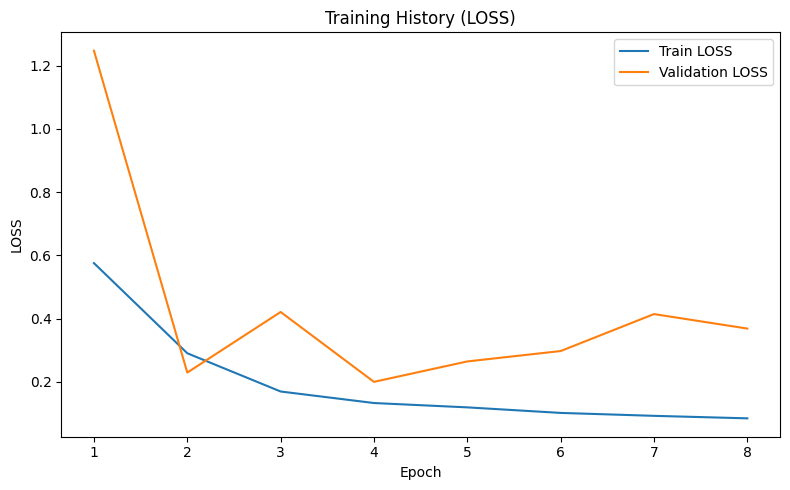

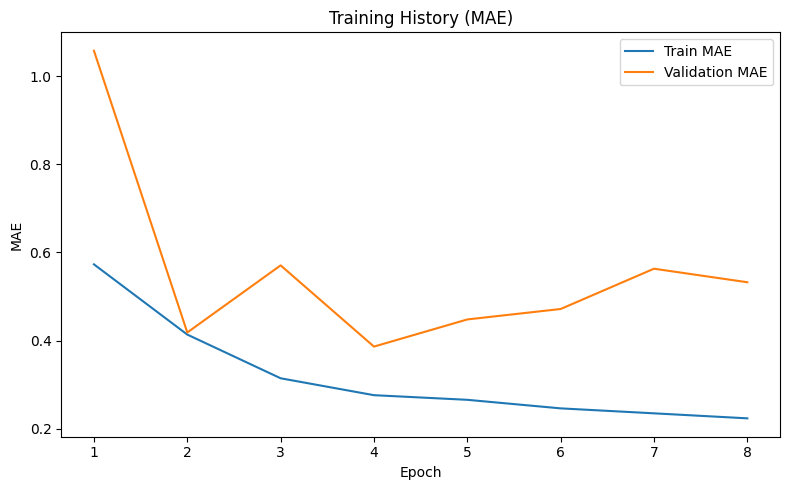

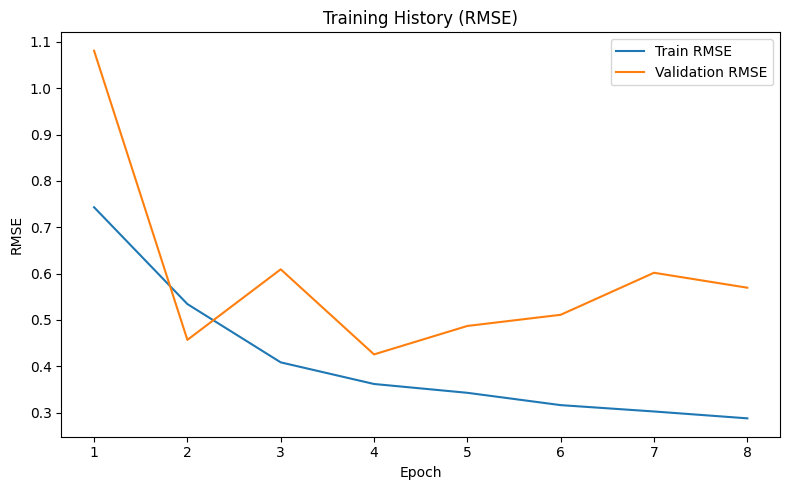

In [30]:
from fx_forecasting.visualization.plots import plot_training_history

plot_training_history(history, metric="loss")
plot_training_history(history, metric="mae")
plot_training_history(history, metric="rmse")

## Evaluation 


Evaluation metrics:
MSE: 0.236810
RMSE: 0.486631
MAE: 0.422195


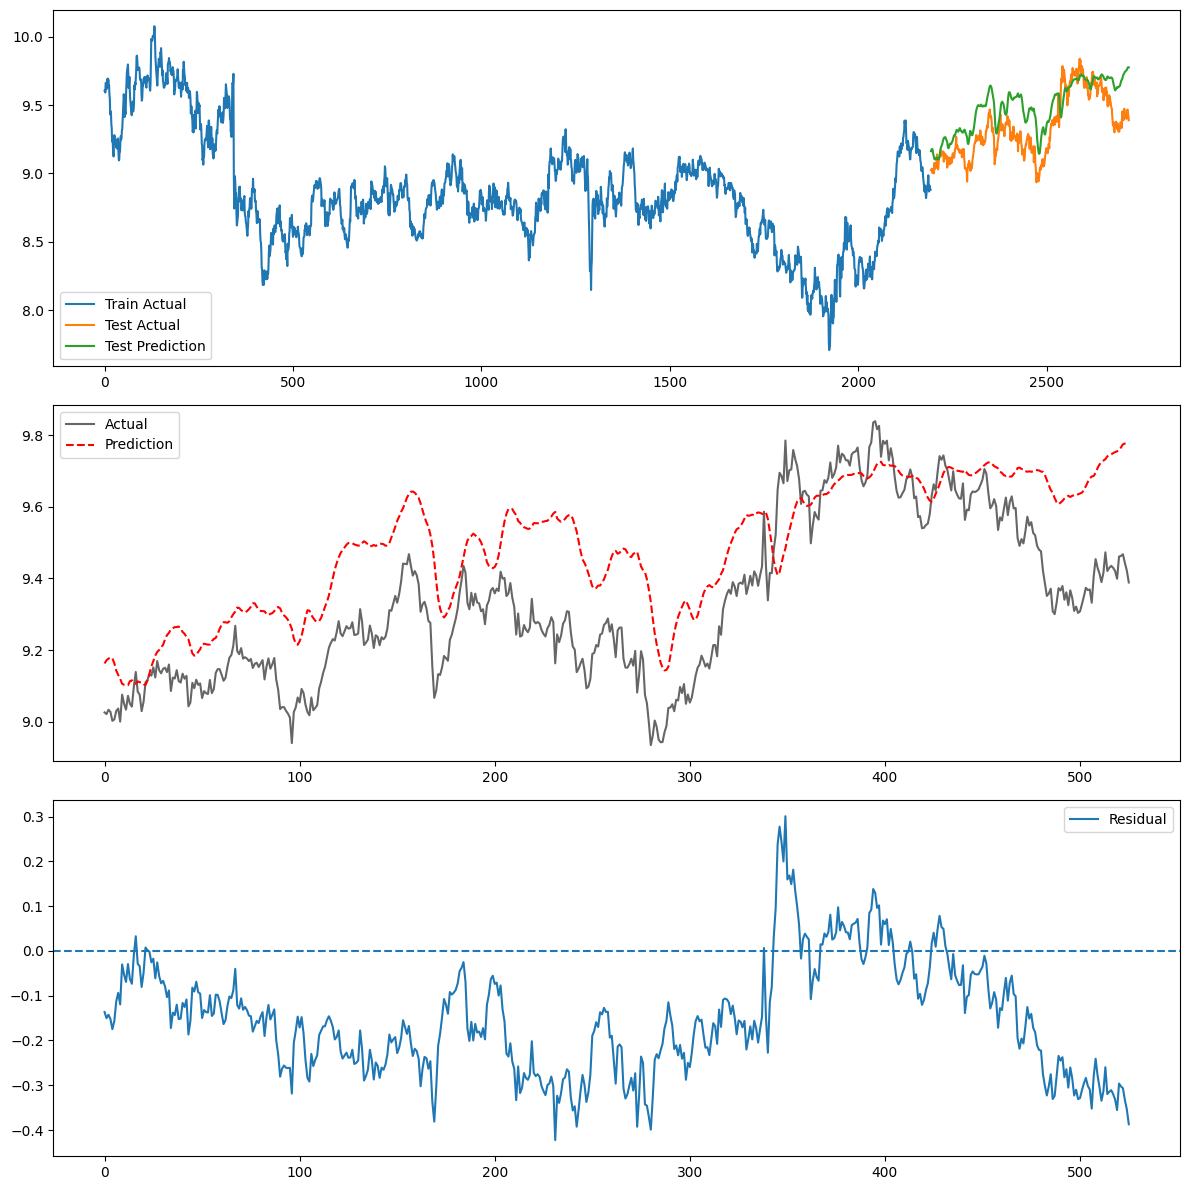

In [26]:
from fx_forecasting.training.evaluate import evaluate_model
from fx_forecasting.visualization.plots import plot_predictions
from fx_forecasting.data.preprocess import inverse_transform_target


preds, targets, metrics = evaluate_model(
    model,
    val_loader,
    device=device
)

# inverse transform
preds_original = inverse_transform_target(
    preds,
    scaler=scaler,
    columns=columns,
    target_col=TARGET,
)

targets_original = inverse_transform_target(
    targets,
    scaler=scaler,
    columns=columns,
    target_col=TARGET,
)

y_train_original = inverse_transform_target(
    y_train,
    scaler=scaler,
    columns=columns,
    target_col=TARGET,
)

plot_predictions(
    preds=preds_original,
    targets=targets_original,
    train_targets=y_train_original
)